In [78]:
# Import Library
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing import image_dataset_from_directory
import matplotlib.pyplot as plt
import os

In [68]:
# Load dataset
dataset_url = "https://storage.googleapis.com/mledu-datasets/cats_and_dogs_filtered.zip"
zip_path = tf.keras.utils.get_file('cats_and_dogs_filtered.zip', origin=dataset_url, extract=True)
data_dir = os.path.join(os.path.dirname(zip_path), 'cats_and_dogs_filtered_extracted', 'cats_and_dogs_filtered')

In [70]:
# Preprocess dateset
train_ds = image_dataset_from_directory(
    os.path.join(data_dir, "train"),
    image_size=(160, 160),
    batch_size=32
)

val_ds = image_dataset_from_directory(
    os.path.join(data_dir, "validation"),
    image_size=(160, 160),
    batch_size=32
)


Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.


In [71]:
# Preprocessing Layer
preprocess = tf.keras.applications.mobilenet_v2.preprocess_input

In [72]:
# Base model (pretrained)
base_model = MobileNetV2(input_shape=(160, 160, 3), include_top=False, weights='imagenet')
base_model.trainable = False # Freeze the base

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [73]:
# Add custom classification head
model = models.Sequential([
    layers.Rescaling(1./127.5, offset=-1, input_shape=(160, 160, 3)),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(1, activation='sigmoid')  # Binary classification
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [74]:
# Compile and Train
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = model.fit(train_ds, validation_data=val_ds, epochs=5)

Epoch 1/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 52s 747ms/step - accuracy: 0.8190 - loss: 0.3838 - val_accuracy: 0.9830 - val_loss: 0.0867
Epoch 2/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 80s 719ms/step - accuracy: 0.9736 - loss: 0.0839 - val_accuracy: 0.9850 - val_loss: 0.0619
Epoch 3/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 82s 716ms/step - accuracy: 0.9807 - loss: 0.0629 - val_accuracy: 0.9830 - val_loss: 0.0521
Epoch 4/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 45s 715ms/step - accuracy: 0.9894 - loss: 0.0428 - val_accuracy: 0.9870 - val_loss: 0.0474
Epoch 5/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 84s 739ms/step - accuracy: 0.9904 - loss: 0.0367 - val_accuracy: 0.9890 - val_loss: 0.0434


In [75]:
# Evaluate
test_loss, test_acc = model.evaluate(val_ds)
print(f'Test accuracy: {test_acc}')

32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 396ms/step - accuracy: 0.9869 - loss: 0.0420
Test accuracy: 0.9890000224113464


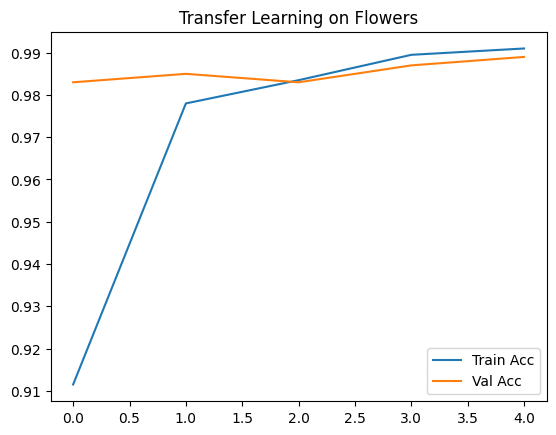

In [79]:
# Plot accuracy
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title('Transfer Learning on Flowers')
plt.show()